<h1>Practice 3 </h1>

---
Markov Chain 1

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
n_state = 10
p = np.zeros((n_state, n_state))
idx = np.arange(n_state)
p[idx, (idx + 1) % n_state] = 0.9
p[idx, (idx - 1) % n_state] = 0.1
# 每一行表示每个每一种状态的可能性，比如p[0] 表示在第一个点的可能性 0.8保持不动 0.1up 0.1down
p[0][0] = 0.8
p[0][1] = 0.1
p[0][-1] = 0.1
print(p)
# axis 是对第几个维度 p[axis0][axis1]
print(f"normalised: {np.all(p.sum(axis=1)==1)}")

[[0.8 0.1 0.  0.  0.  0.  0.  0.  0.  0.1]
 [0.1 0.  0.9 0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.1 0.  0.9 0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.1 0.  0.9 0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.1 0.  0.9 0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.1 0.  0.9 0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.1 0.  0.9 0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.1 0.  0.9 0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.1 0.  0.9]
 [0.9 0.  0.  0.  0.  0.  0.  0.  0.1 0. ]]
normalised: False


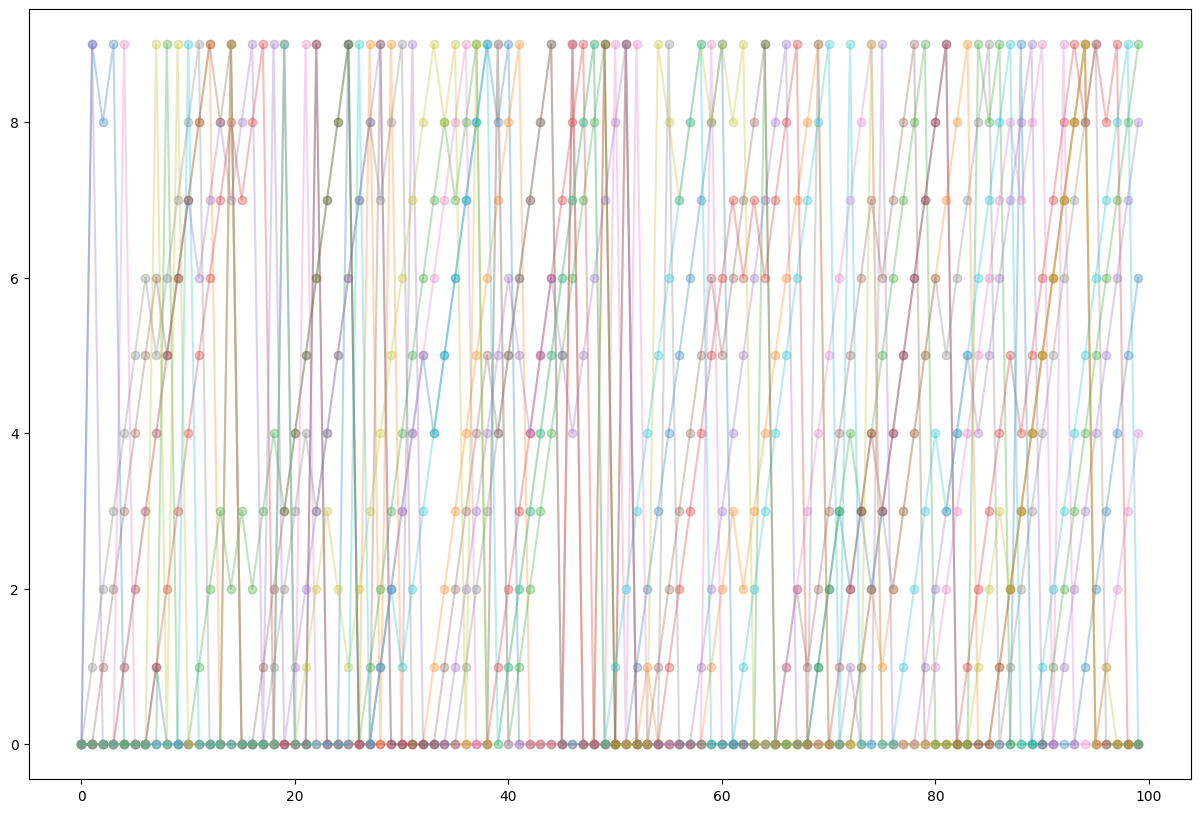

In [11]:
def sample_episodes(n_episodes, length_episodes):
    episodes = np.zeros((n_episodes, length_episodes), dtype=int)
    for idx_episodes in range(n_episodes):
        for idx_time in range(1, length_episodes):
            # 对于每个点获取他的下一个状态
            current_state = episodes[idx_episodes, idx_time - 1]
            # 当前是几就读取几的可能性 对应的是p第几行
            probs = p[current_state]
            next_state = np.random.choice(n_state, p=probs)
            episodes[idx_episodes, idx_time] = next_state
    return episodes
# 10个样本每个学习100次 所在位置的图
episodes = sample_episodes(n_episodes=10, length_episodes=100)
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
ax.plot(np.arange(episodes.shape[1]), episodes.T, '-o', alpha=0.3);

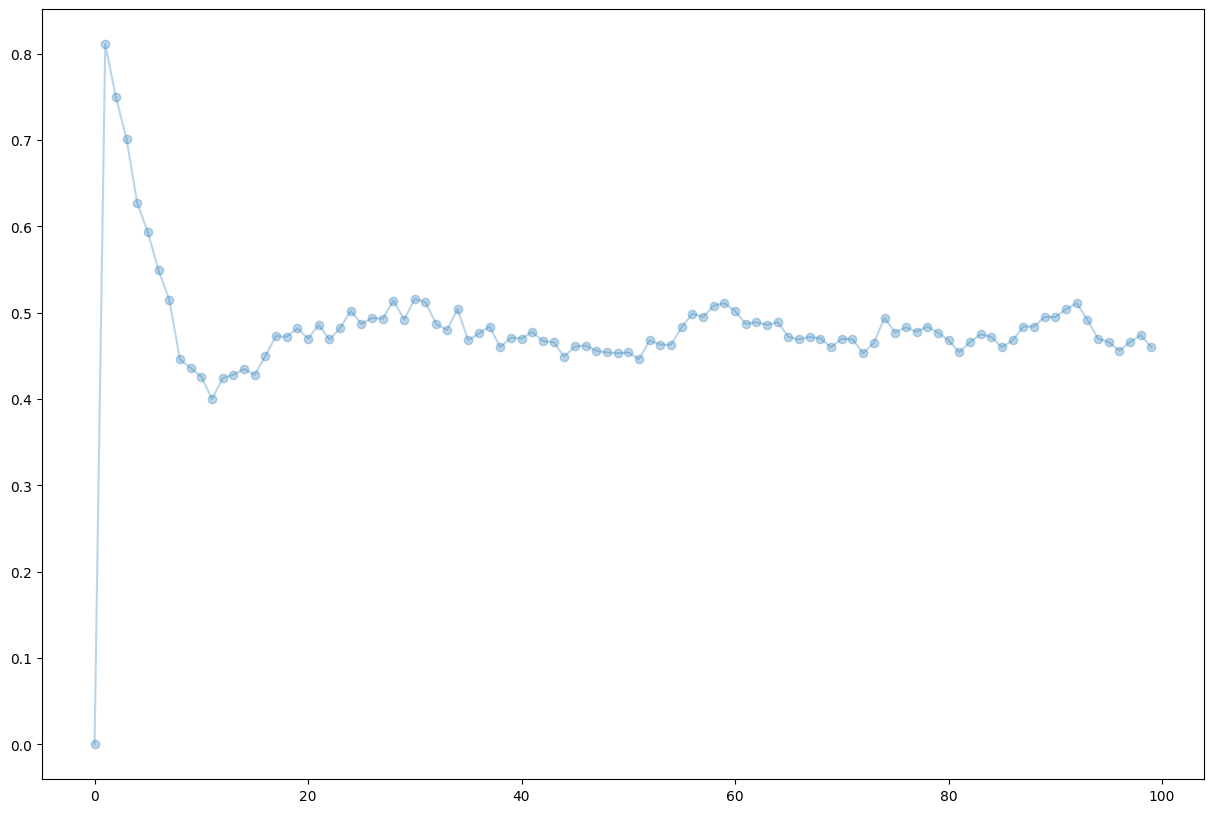

In [12]:
# 马可夫奖励
def reward(state):
    return int(state == 0)

def sample_episodes(n_episodes, length_episodes):
    episodes = np.zeros((n_episodes, length_episodes, 2), dtype=int)
    for idx_episodes in range(n_episodes):
        for idx_time in range(1, length_episodes):
            # 对于每个点获取他的下一个状态
            current_state = episodes[idx_episodes, idx_time - 1, 0]
            # 当前是几就读取几的可能性 对应的是p第几行
            probs = p[current_state]
            next_state = np.random.choice(n_state, p=probs)
            episodes[idx_episodes, idx_time, 0] = next_state
            episodes[idx_episodes, idx_time, 1] = reward(next_state)
    return episodes
episodes = sample_episodes(n_episodes=1000, length_episodes=100)
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
ax.plot(np.arange(episodes.shape[1]), episodes[:, :, 1].mean(axis=0), '-o', alpha=0.3);

In [ ]:
# 添加折扣函数
